<a href="https://colab.research.google.com/github/TienManh15072007/AI_HOMEWORK1/blob/main/AI_HOMEWORK2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 24.1 MB/s eta 0:00:00


In [49]:
#BÀI 2.11
import skfuzzy as fuzz
import numpy as np
from skfuzzy import control as ctrl

Ride_distance = ctrl.Antecedent(np.arange(0, 51, 1), 'Ride_distance')
Traffic_condition = ctrl.Antecedent(np.arange(0,101,1),"Traffic_condition")
Demand_level= ctrl.Antecedent(np.arange(0,101,1),"Demand_level")
Weather_condition= ctrl.Antecedent(np.arange(0,11,1),"Weather_condition")
Customer_rating= ctrl.Antecedent(np.arange(1,5.5,0.5),"Customer_rating")
Ride_punctuality=  ctrl.Antecedent(np.arange(0,101,1),"Ride_punctuality")
Ride_price = ctrl.Consequent(np.arange(0,101,1),"Ride_price") #0 đến 100 đô la
Plus_point = ctrl.Consequent(np.arange(0,31,1),"Plus_point")


Ride_distance['short'] = fuzz.trimf(Ride_distance.universe, [0, 0,3])
Ride_distance['medium'] = fuzz.trimf(Ride_distance.universe, [2, 5, 8])
Ride_distance['long'] = fuzz.trimf(Ride_distance.universe, [6, 13, 20])
Ride_distance['very_long'] = fuzz.trimf(Ride_distance.universe, [15, 32.5, 50])

Traffic_condition["low"]=fuzz.trimf(Traffic_condition.universe,[0,0,30])
Traffic_condition["medium"]=fuzz.trimf(Traffic_condition.universe,[20,45,70])
Traffic_condition["high"]=fuzz.trimf(Traffic_condition.universe,[60,100,100])

Demand_level["low"]=fuzz.trimf(Demand_level.universe,[0,0,30])
Demand_level["medium"]=fuzz.trimf(Demand_level.universe,[20,45,70])
Demand_level["high"]=fuzz.trimf(Demand_level.universe,[60,100,100])
Weather_condition["good"]=fuzz.trimf(Weather_condition.universe,[0,10,10])
Weather_condition["moderate"]=fuzz.trimf(Weather_condition.universe,[0,5,10])
Weather_condition["bad"]=fuzz.trimf(Weather_condition.universe,[0,0,5])
Customer_rating["poor"]=fuzz.trimf(Customer_rating.universe,[0,0,2.5])
Customer_rating["average"]=fuzz.trimf(Customer_rating.universe,[0,2.5,5])
Customer_rating["good"]=fuzz.trimf(Customer_rating.universe,[2.5,5,5])
Ride_punctuality["late"]=fuzz.trimf(Ride_punctuality.universe,[0,0,50])
Ride_punctuality["on_time"]=fuzz.trimf(Ride_punctuality.universe,[40,60,80]) # Added 'on_time'
Ride_punctuality["early"]=fuzz.trimf(Ride_punctuality.universe,[70,85,100])
Ride_price["low"]=fuzz.trimf(Ride_price.universe,[0,0,10])
Ride_price["medium"]=fuzz.trimf(Ride_price.universe,[10,30,50])
Ride_price["high"]=fuzz.trimf(Ride_price.universe,[40,60,80]) # Corrected universe
Ride_price["veryhigh"] =fuzz.trimf(Ride_price.universe,[80,90,100])
Plus_point["none"]=fuzz.trimf(Plus_point.universe,[0,0,10])
Plus_point["moderate"]=fuzz.trimf(Plus_point.universe,[5,12.5,20])
Plus_point["high"]=fuzz.trimf(Plus_point.universe,[18,24,30])
rule1=ctrl.Rule(Ride_distance['short']&Traffic_condition['low']&Demand_level['low'],Ride_price['low'])
rule2=ctrl.Rule(Ride_distance['short']&Traffic_condition['medium']&Demand_level['high'],Ride_price['medium'])
rule3=ctrl.Rule(Ride_distance['medium']&Traffic_condition['high']&Demand_level['high'],Ride_price['high'])
rule4=ctrl.Rule(Ride_distance['long']&Traffic_condition['medium']&Weather_condition['good'],Ride_price['medium'])
rule5=ctrl.Rule(Ride_distance['long']&Traffic_condition['high']&Weather_condition['bad'],Ride_price['veryhigh'])
rule6=ctrl.Rule(Ride_distance['very_long']&Traffic_condition['high']&Demand_level['high'],Ride_price['veryhigh'])
rule7=ctrl.Rule(Ride_distance['medium']&Traffic_condition['low']&Demand_level['low'],Ride_price['medium'])
rule8=ctrl.Rule(Ride_distance['short']&Traffic_condition['high']&Weather_condition['bad'],Ride_price['high'])
rule9=ctrl.Rule(Ride_distance['very_long']&Weather_condition['bad'],Ride_price['veryhigh'])
rule10=ctrl.Rule(Ride_distance['medium']&Traffic_condition['medium']&Weather_condition['moderate'],Ride_price['medium'])
rule11=ctrl.Rule(Customer_rating['good']&Ride_punctuality['early'],Plus_point['high'])
rule12=ctrl.Rule(Customer_rating['average']&Ride_punctuality['on_time'],Plus_point['moderate'])
rule13=ctrl.Rule(Customer_rating['poor']&Ride_punctuality['late'],Plus_point['none'])
rule14=ctrl.Rule(Ride_distance['long']&Traffic_condition['high']&Ride_punctuality['on_time'],Plus_point['high'])
rule15=ctrl.Rule(Ride_distance['medium']&Traffic_condition['medium']&Customer_rating['good'],Plus_point['moderate'])
rule16=ctrl.Rule(Ride_distance['short']&Customer_rating['good']&Ride_punctuality['early'],Plus_point['high'])
rule17=ctrl.Rule(Ride_distance['very_long']&Weather_condition['bad']&Customer_rating['good'],Plus_point['high'])
rule18=ctrl.Rule(Ride_distance['short']&Customer_rating['average']&Ride_punctuality['on_time'],Plus_point['none'])
rule19=ctrl.Rule(Ride_distance['long']&Traffic_condition['high']&Ride_punctuality['late'],Plus_point['none'])
rule20=ctrl.Rule(Ride_distance['medium']&Weather_condition['moderate']&Customer_rating['good'],Plus_point['moderate'])
Optimization_strategy_ctrl = ctrl.ControlSystem([
    rule1,rule2,rule3,rule4,rule5,rule6,rule7,rule8,rule9,
    rule10,rule11,rule12,rule13,rule14,rule15,rule16,rule17,rule18,
    rule19,rule20,])
Optimization_strategy = ctrl.ControlSystemSimulation(Optimization_strategy_ctrl)

Optimization_strategy.input['Ride_distance'] = 10
Optimization_strategy.input['Traffic_condition'] = 50
Optimization_strategy.input['Demand_level'] = 80
Optimization_strategy.input['Weather_condition'] = 5
Optimization_strategy.input['Customer_rating'] = 4
Optimization_strategy.input['Ride_punctuality'] = 70



Optimization_strategy.compute()
print("Giá xe dự đoán:", Optimization_strategy.output['Ride_price'])
print("Điểm thưởng tài xế:", Optimization_strategy.output['Plus_point'])





Giá xe dự đoán: 30.000000000000004
Điểm thưởng tài xế: 12.500000000000005


Khuyến mãi tối ưu: 55.000000000000036


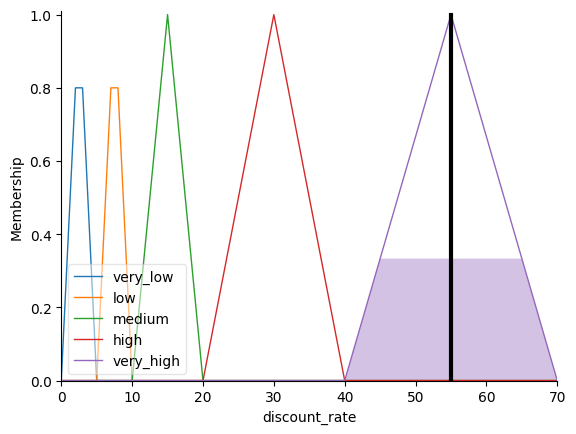

In [38]:
#BÀI 2.12
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

store_rating = ctrl.Antecedent(np.arange(0, 5.1, 0.1), 'store_rating')
sales_volume = ctrl.Antecedent(np.arange(0, 101, 1), 'sales_volume')
profit_margin = ctrl.Antecedent(np.arange(0, 101, 1), 'profit_margin')
seasonal = ctrl.Antecedent(np.arange(0, 11, 1), 'seasonal')
competitor_discount = ctrl.Antecedent(np.arange(0, 101, 1), 'competitor_discount')

discount_rate = ctrl.Consequent(np.arange(0, 71, 1), 'discount_rate')

store_rating['low'] = fuzz.trimf(store_rating.universe, [0, 0, 4.0])
store_rating['medium'] = fuzz.trimf(store_rating.universe, [3.5, 4.25, 4.6])
store_rating['high'] = fuzz.trimf(store_rating.universe, [4.5, 5.0, 5.0])

sales_volume['low'] = fuzz.trimf(sales_volume.universe, [0, 0, 40])
sales_volume['medium'] = fuzz.trimf(sales_volume.universe, [30, 50, 70])
sales_volume['high'] = fuzz.trimf(sales_volume.universe, [60, 100, 100])

profit_margin['low'] = fuzz.trimf(profit_margin.universe, [0, 0, 30])
profit_margin['medium'] = fuzz.trimf(profit_margin.universe, [20, 50, 80])
profit_margin['high'] = fuzz.trimf(profit_margin.universe, [70, 100, 100])

seasonal['none'] = fuzz.trimf(seasonal.universe, [0, 0, 3])
seasonal['moderate'] = fuzz.trimf(seasonal.universe, [2, 5, 8])
seasonal['high'] = fuzz.trimf(seasonal.universe, [7, 10, 10])

competitor_discount['low'] = fuzz.trimf(competitor_discount.universe, [0, 0, 30])
competitor_discount['medium'] = fuzz.trimf(competitor_discount.universe, [20, 50, 80])
competitor_discount['high'] = fuzz.trimf(competitor_discount.universe, [70, 100, 100])

discount_rate['very_low'] = fuzz.trimf(discount_rate.universe, [0, 2.5, 5])
discount_rate['low'] = fuzz.trimf(discount_rate.universe, [5, 7.5, 10])
discount_rate['medium'] = fuzz.trimf(discount_rate.universe, [10, 15, 20])
discount_rate['high'] = fuzz.trimf(discount_rate.universe, [20, 30, 40])
discount_rate['very_high'] = fuzz.trimf(discount_rate.universe, [40, 55, 70])

rule1 = ctrl.Rule(store_rating['high'] & sales_volume['high'] & profit_margin['high'], discount_rate['very_low'])
rule2 = ctrl.Rule(store_rating['low'] & sales_volume['low'] & profit_margin['high'], discount_rate['high'])
rule3 = ctrl.Rule(seasonal['high'] & competitor_discount['high'], discount_rate['very_high'])
rule4 = ctrl.Rule(store_rating['medium'] & sales_volume['medium'] & profit_margin['medium'], discount_rate['medium'])
rule5 = ctrl.Rule(competitor_discount['low'] & profit_margin['low'] & sales_volume['high'], discount_rate['very_low'])
rule6 = ctrl.Rule(store_rating['low'] & seasonal['none'], discount_rate['medium'])
rule7 = ctrl.Rule(sales_volume['low'] & profit_margin['low'], discount_rate['very_high'])

discount_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7])
discount_optimization = ctrl.ControlSystemSimulation(discount_ctrl)

discount_optimization.input['store_rating'] = 4.3
discount_optimization.input['sales_volume'] = 50
discount_optimization.input['profit_margin'] = 20
discount_optimization.input['seasonal'] = 9
discount_optimization.input['competitor_discount'] = 80

discount_optimization.compute()

print("Khuyến mãi tối ưu:",discount_optimization.output['discount_rate'])

discount_rate.view(sim=discount_optimization)

GIÁ BÁN TỐI ƯU: 14.999999999999998


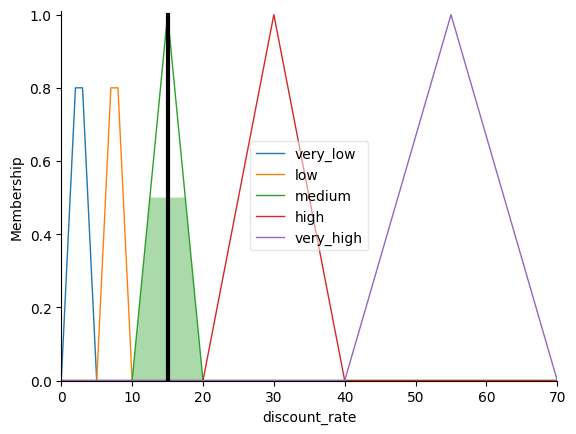

In [43]:
#BÀI 2.13
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

demand = ctrl.Antecedent(np.arange(0, 101, 1), 'demand')
price_pressure = ctrl.Antecedent(np.arange(0, 101, 1), 'price_pressure')
reputation = ctrl.Antecedent(np.arange(0, 5.1, 0.1), 'reputation')
profit_margin = ctrl.Antecedent(np.arange(0, 101, 1), 'profit_margin')
seasonal_demand = ctrl.Antecedent(np.arange(0, 11, 1), 'seasonal_demand')

discount_rate = ctrl.Consequent(np.arange(0, 71, 1), 'discount_rate')

demand['low'] = fuzz.trimf(demand.universe, [0, 0, 40])
demand['medium'] = fuzz.trimf(demand.universe, [30, 50, 70])
demand['high'] = fuzz.trimf(demand.universe, [60, 100, 100])

price_pressure['low'] = fuzz.trimf(price_pressure.universe, [0, 0, 40])
price_pressure['medium'] = fuzz.trimf(price_pressure.universe, [30, 50, 70])
price_pressure['high'] = fuzz.trimf(price_pressure.universe, [60, 100, 100])

reputation['low'] = fuzz.trimf(reputation.universe, [0, 0, 4.0])
reputation['medium'] = fuzz.trimf(reputation.universe, [3.8, 4.2, 4.5])
reputation['high'] = fuzz.trimf(reputation.universe, [4.4, 5.0, 5.0])

profit_margin['low'] = fuzz.trimf(profit_margin.universe, [0, 0, 40])
profit_margin['medium'] = fuzz.trimf(profit_margin.universe, [30, 50, 70])
profit_margin['high'] = fuzz.trimf(profit_margin.universe, [60, 100, 100])

seasonal_demand['none'] = fuzz.trimf(seasonal_demand.universe, [0, 0, 4])
seasonal_demand['medium'] = fuzz.trimf(seasonal_demand.universe, [3, 6, 8])
seasonal_demand['high'] = fuzz.trimf(seasonal_demand.universe, [7, 10, 10])

discount_rate['very_low'] = fuzz.trimf(discount_rate.universe, [0, 2.5, 5])
discount_rate['low'] = fuzz.trimf(discount_rate.universe, [5, 7.5, 10])
discount_rate['medium'] = fuzz.trimf(discount_rate.universe, [10, 15, 20])
discount_rate['high'] = fuzz.trimf(discount_rate.universe, [20, 30, 40])
discount_rate['very_high'] = fuzz.trimf(discount_rate.universe, [40, 55, 70])

rule1 = ctrl.Rule(demand['high'] & price_pressure['low'] & profit_margin['low'], discount_rate['very_low'])
rule2 = ctrl.Rule(demand['low'] & price_pressure['high'] & profit_margin['high'], discount_rate['high'])
rule3 = ctrl.Rule(reputation['high'] & profit_margin['medium'] & seasonal_demand['high'], discount_rate['medium'])
rule4 = ctrl.Rule(price_pressure['high'] & seasonal_demand['high'] & profit_margin['high'], discount_rate['very_high'])
rule5 = ctrl.Rule(reputation['low'] & demand['medium'] & profit_margin['low'], discount_rate['medium'])
rule6 = ctrl.Rule(demand['high'] & seasonal_demand['none'] & price_pressure['low'], discount_rate['very_low'])
rule7 = ctrl.Rule(profit_margin['high'] & price_pressure['medium'] & seasonal_demand['medium'], discount_rate['medium'])

selling_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7])
selling_optimization = ctrl.ControlSystemSimulation(selling_ctrl)

selling_optimization.input['demand'] = 85
selling_optimization.input['price_pressure'] = 50
selling_optimization.input['reputation'] = 4.2
selling_optimization.input['profit_margin'] = 80
selling_optimization.input['seasonal_demand'] = 6
selling_optimization.compute()

print("GIÁ BÁN TỐI ƯU:",selling_optimization.output['discount_rate'])

discount_rate.view(sim=selling_optimization)


4.999999999999999
49.99999999999999


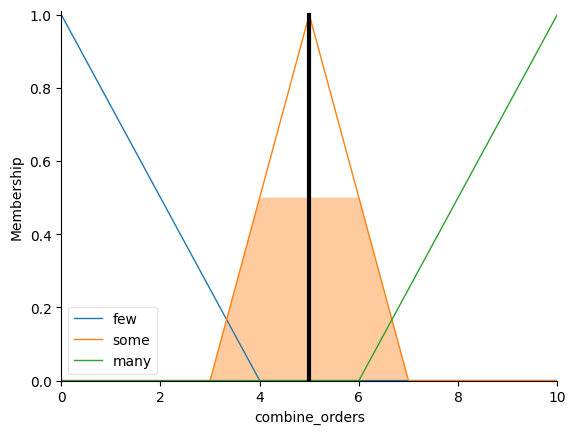

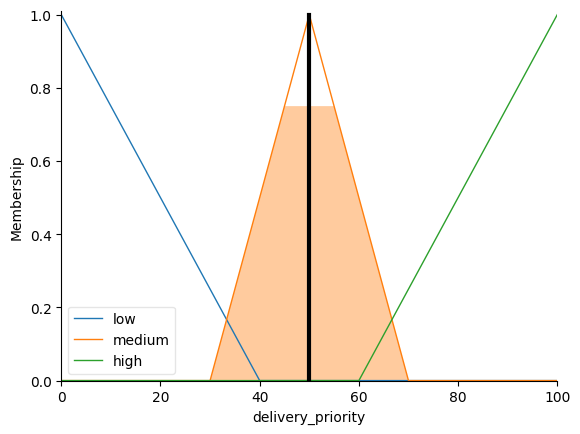

In [48]:
#BÀI 2.14
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

order_density = ctrl.Antecedent(np.arange(0, 101, 1), 'order_density')
delivery_urgency = ctrl.Antecedent(np.arange(0, 101, 1), 'delivery_urgency')
driver_load = ctrl.Antecedent(np.arange(0, 101, 1), 'driver_load')
traffic_conditions = ctrl.Antecedent(np.arange(0, 101, 1), 'traffic_conditions')
profit_per_delivery = ctrl.Antecedent(np.arange(0, 101, 1), 'profit_per_delivery')

combine_orders = ctrl.Consequent(np.arange(0, 11, 1), 'combine_orders')
delivery_priority = ctrl.Consequent(np.arange(0, 101, 1), 'delivery_priority')

order_density['low'] = fuzz.trimf(order_density.universe, [0, 0, 40])
order_density['medium'] = fuzz.trimf(order_density.universe, [30, 50, 70])
order_density['high'] = fuzz.trimf(order_density.universe, [60, 100, 100])

delivery_urgency['low'] = fuzz.trimf(delivery_urgency.universe, [0, 0, 40])
delivery_urgency['medium'] = fuzz.trimf(delivery_urgency.universe, [30, 50, 70])
delivery_urgency['high'] = fuzz.trimf(delivery_urgency.universe, [60, 100, 100])

driver_load['low'] = fuzz.trimf(driver_load.universe, [0, 0, 40])
driver_load['medium'] = fuzz.trimf(driver_load.universe, [30, 50, 70])
driver_load['high'] = fuzz.trimf(driver_load.universe, [60, 100, 100])

traffic_conditions['low'] = fuzz.trimf(traffic_conditions.universe, [0, 0, 40])
traffic_conditions['medium'] = fuzz.trimf(traffic_conditions.universe, [30, 50, 70])
traffic_conditions['high'] = fuzz.trimf(traffic_conditions.universe, [60, 100, 100])

profit_per_delivery['low'] = fuzz.trimf(profit_per_delivery.universe, [0, 0, 40])
profit_per_delivery['medium'] = fuzz.trimf(profit_per_delivery.universe, [30, 50, 70])
profit_per_delivery['high'] = fuzz.trimf(profit_per_delivery.universe, [60, 100, 100])

combine_orders['few'] = fuzz.trimf(combine_orders.universe, [0, 0, 4])
combine_orders['some'] = fuzz.trimf(combine_orders.universe, [3, 5, 7])
combine_orders['many'] = fuzz.trimf(combine_orders.universe, [6, 10, 10])

delivery_priority['low'] = fuzz.trimf(delivery_priority.universe, [0, 0, 40])
delivery_priority['medium'] = fuzz.trimf(delivery_priority.universe, [30, 50, 70])
delivery_priority['high'] = fuzz.trimf(delivery_priority.universe, [60, 100, 100])

rule1 = ctrl.Rule(order_density['high'] & driver_load['low'] & traffic_conditions['low'], combine_orders['many'])
rule2 = ctrl.Rule(order_density['medium'] & traffic_conditions['high'] & delivery_urgency['medium'], combine_orders['some'])
rule3 = ctrl.Rule(driver_load['high'] & order_density['high'] & profit_per_delivery['medium'], combine_orders['some'])
rule4 = ctrl.Rule(order_density['low'] & delivery_urgency['high'] & traffic_conditions['medium'], combine_orders['some'])
rule5 = ctrl.Rule(profit_per_delivery['high'] & delivery_urgency['high'] & traffic_conditions['low'], combine_orders['some'])
rule6 = ctrl.Rule(delivery_urgency['high'] & profit_per_delivery['high'], delivery_priority['high'])
rule7 = ctrl.Rule(delivery_urgency['medium'] & traffic_conditions['medium'], delivery_priority['medium'])
rule8 = ctrl.Rule(delivery_urgency['low'] & order_density['high'] & profit_per_delivery['low'], delivery_priority['low'])
rule9 = ctrl.Rule(order_density['high'] & driver_load['low'] & traffic_conditions['medium'], combine_orders['some']) # New rule to ensure combine_orders fires with traffic_conditions = 45

logistics_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8, rule9]) # Added rule9
logistics_sim = ctrl.ControlSystemSimulation(logistics_ctrl)

logistics_sim.input['order_density'] = 85
logistics_sim.input['delivery_urgency'] = 55
logistics_sim.input['driver_load'] = 20
logistics_sim.input['traffic_conditions'] = 45
logistics_sim.input['profit_per_delivery'] = 60

logistics_sim.compute()

print(logistics_sim.output['combine_orders'])
print(logistics_sim.output['delivery_priority'])

combine_orders.view(sim=logistics_sim)
delivery_priority.view(sim=logistics_sim)